## Figure 11. storm speed

In [2]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [3]:
# import plottig functions
from pathlib import Path
import sys
# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.diagnostic_plots import circular_percentile, circular_mean, circular_trend, circular_trend_permutation_test

In [4]:
# ── 1) LOAD GRID ─────────────────────────────────────────────────────────────
shp_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Projects/Cartography/CONUS_5d_grid.shp"
grid = gpd.read_file(shp_path)

# Make sure we’re in geographic coordinates for Cartopy plotting
grid = grid.to_crs(epsg=4326)

In [5]:
f = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/CONUS_storm_tracking/Storm_Tracking_Stats'
storm_stats = os.listdir(f)
storm_stats = [file for file in storm_stats if file.endswith('.csv')]

centroids = grid.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

domains = pd.DataFrame(index=grid['D_name'], columns=["x", "y"])
domains["x"] = xs
domains["y"] = ys

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_59666/4044105814.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid.geometry.centroid


In [6]:
## function for domain stats
def _month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Fall'


def _compute_variable_stats(df_subset, key, perform_direction_trend=False):
    row = {}

    if key == 'dir':
        directions = df_subset['storm_direction'].dropna()
        if directions.empty:
            return row

        row['mean'] = circular_mean(directions)
        row['median'] = circular_percentile(directions, 50)
        row['p75'] = circular_percentile(directions, 75)
        row['p25'] = circular_percentile(directions, 25)
        row['p5'] = circular_percentile(directions, 5)
        row['p95'] = circular_percentile(directions, 95)
        row['max'] = directions.max()
        row['min'] = directions.min()

        if perform_direction_trend:
            df_year = df_subset.resample('YE').apply(lambda x: x.loc[x['mean_intensity'].idxmax()])
            x = np.arange(len(df_year))
            if len(df_year) > 1 and df_year['storm_direction'].nunique() > 1:
                results = circular_trend_permutation_test(x, df_year['storm_direction'], n_permutations=10000)
                row['trend'] = results['rate_direction_deg']
                row['p_value'] = results['p_value']
            else:
                row['trend'] = np.nan
                row['p_value'] = np.nan

    elif key == 'speed':
        values = df_subset['storm_velocity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'intensity':
        values = df_subset['mean_intensity'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'area':
        values = df_subset['area'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)
        row['max'] = values.max()
        row['min'] = values.min()

    elif key == 'angular_var':
        values = df_subset['angular_variance_weighted'].dropna()
        if values.empty:
            return row

        row['mean'] = values.mean()
        row['median'] = values.median()
        row['p75'] = np.percentile(values, 75)
        row['p25'] = np.percentile(values, 25)

    return row


def compute_stats_by_season(df, key, perform_direction_trend=False):
    season_groups = {'ALL': df}
    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_groups[season] = df[df['season'] == season]

    seasonal_stats = {}
    for season_name, season_df in season_groups.items():
        seasonal_stats[season_name] = _compute_variable_stats(
            season_df,
            key,
            perform_direction_trend=(perform_direction_trend and season_name == 'ALL'),
        )
    return seasonal_stats


def domain_stats_func(top_storms, perform_direction_trend=False, filter_events=False, linear_trajectory_threshold=0.51):
    variable_keys = ['dir', 'speed', 'intensity', 'area', 'angular_var']
    season_keys = ['ALL', 'Winter', 'Spring', 'Summer', 'Fall']
    stats = {key: {season: pd.DataFrame() for season in season_keys} for key in variable_keys}

    for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()
        # filter by linear trajectory threshold
        if filter_events:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        # get the date from the domain name
        df.index = pd.to_datetime(df['storm_event'].str.split('_').str[4].str[:8], format='%Y%m%d')
        df.drop(columns=['storm_event'], inplace=True)
        df = df.sort_values(by=df.index.name)
        df['season'] = df.index.month.map(_month_to_season)

        domain_x = domains.loc[cat]['x']
        domain_y = domains.loc[cat]['y']

        for key in variable_keys:
            seasonal_stats = compute_stats_by_season(
                df,
                key,
                perform_direction_trend=perform_direction_trend,
            )

            for season_name, values in seasonal_stats.items():
                for stat_name, stat_value in values.items():
                    stats[key][season_name].loc[cat, stat_name] = stat_value
                stats[key][season_name].loc[cat, 'centroid_x'] = domain_x
                stats[key][season_name].loc[cat, 'centroid_y'] = domain_y

    for key in variable_keys:
        for season_name in season_keys:
            stats[key][season_name].reset_index(inplace=True)
            stats[key][season_name].rename(columns={'index': 'Domain'}, inplace=True)

    return stats

## Speed distributions by seasons

In [7]:
from scipy.stats import gaussian_kde
import matplotlib.patheffects as pe
import warnings

def plot_density_on_ax(ax, data, bw=0.5, percentiles = "5-95", percentile_labels=True):
    """
    Plots a probability density (KDE) onto a *pre-existing* matplotlib
    axes (ax), using its limits as the fixed box.

    Removes all axis spines, ticks, and labels from the ax.

    Parameters:
    - ax (matplotlib.axes.Axes): The axes object to draw on.
    - data (array-like): The 1D data array.
    """
    # --- 1. Get Box Limits from the Axes ---
    # The box is defined by the limits of the axes it's drawn on
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # --- 2. Calculate Statistics ---
    try:
        p5, p25, p50, p75, p95 = np.percentile(data, [5, 25, 50, 75, 95])
    except IndexError:
        warnings.warn("Cannot calculate percentiles, data may be empty.")
        return

    # --- 3. Estimate and Plot Density ---
    try:
        kde = gaussian_kde(data, bw_method=bw)
    except (np.linalg.LinAlgError, ValueError):
        warnings.warn("Could not compute KDE, possibly due to insufficient data.")
        return

    # Create an x-grid *within the plot boundaries*
    x_grid = np.linspace(xmin, xmax, 500)
    density = kde(x_grid)

    # Plot the density curve and fill
    ax.plot(x_grid, density, color='black', linewidth=1)
    ax.fill_between(x_grid, density, alpha=0.6, color='lightblue')

    # --- 4. Add Percentile Lines ---
    # Use the box's ymin and ymax
    ymax = density.max() * 1.1 # Extend ymax slightly to ensure percentile lines are visible above the density curve
    if percentiles == "5-95":
        ax.vlines(
            [p5, p95], ymin=ymin, ymax=ymax,
            color='#D95319', linestyle='--', linewidth=0.8)
    else:
        ax.vlines([p25, p75], ymin=ymin, ymax=ymax,
            color='#D95319', linestyle='--', linewidth=0.8)
    
    ax.vlines(
        p50, ymin=ymin, ymax=ymax,
        color='#0072BD', linestyle='-', linewidth=1.5,
    )
    # Add text for showing the median value below the median line
    
    ax.text(
        (xmax+xmin)/2, ymax*1.2, f'{p50:.2f}',
        color='#0072BD', fontsize=12, ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
    )
    if percentile_labels:
        if percentiles == "5-95":
            p1, p2 = p5, p95
        else:
            p1, p2 = p25, p75

        ax.text(
            (xmax+xmin)/2, ymax, f'({p1:.2f},{p2:.2f})',
            color='#D95319', fontsize=9, ha='center', va='bottom', path_effects=[pe.withStroke(linewidth=2.5, foreground="white")]
        )
     


    # remove background color to make it transparent
    ax.set_facecolor('none')
    # --- 5. Remove All Axis Chrome ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

def plot_kde_legend(
    ax,
    xlim=(0.0, 1.0),
    percentiles=(5, 25, 50, 75, 95),
    v_max=1.0,
    show_formula=True,
    fill_color="lightblue",
    line_color="black",
    p_median_color="#0072BD",
    p_other_color="#D95319",
    fontsize=12
):
    """
    Draw a generic KDE 'legend' that explains the elements used in your inset plots.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw on (created by caller).
    xlim : (float, float)
        X-axis limits used in your real KDE plots; using the same makes the legend consistent.
    percentiles : iterable of ints
        Which percentile markers to show (default: 5,25,50,75,95).
    kde_label : str
        Text placed inside/near the curve describing the KDE.
    fill_color, line_color : str
        Colors for the density fill and outline.
    p_median_color, p_other_color : str
        Colors for the median (50th) and the other percentile lines.
    fontsize : int
        Base text size for labels.
    """
    xmin, xmax = xlim
    xspan = xmax - xmin
    if xspan <= 0:
        xmax = xmin + 1.0
        xspan = 1.0

    # --- 1) Make a generic bell-shaped "KDE" curve scaled to xlim ---
    x = np.linspace(xmin, xmax, 600)
    mu = xmin + 0.5 * xspan
    sigma = max(xspan / 6.0, 1e-9)  # keep visible
    y = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    y /= y.max()  # normalize to [0,1]

    # Reserve headroom for labels above the lines
    y_top = 1.05
    ax.plot(x, y, color=line_color, lw=1.2)
    ax.fill_between(x, y, 0, color=fill_color, alpha=0.7)


    # --- 2) Percentile lines + names ---
    def pct_to_x(p):
        return xmin + (p / 100.0) * xspan

    for p in percentiles:
        xv = pct_to_x(p)
        color = p_median_color if p == 50 else p_other_color
        ls = "-" if p == 50 else "--"
        lw = 1.6 if p == 50 else 1.0

        # vertical line
        ax.vlines(xv, 0, y_top, colors=color, linestyles=ls, linewidth=lw)

        # label on top of each line
        if p == 50:
            label = "P50"
        else:
            label = f"P{p}"

        ax.text(
            xv, y_top, label,
            rotation=0, ha="center", va="bottom",
            color=color, fontsize=fontsize
        )
    ## add text below the kde curve
    ax.text(
        (xmin + xmax) / 2, -0.05,
        "",
        fontsize=fontsize+2, ha="center", va="top"
    )
    ## add text for max and min value at the two ends
    ax.text(
        xmin, -0.05,
        "0",
        fontsize=fontsize, ha="left", va="top"
    )
    ax.text(
        xmax, -0.05,
        f"{int(v_max)}",
        fontsize=fontsize, ha="right", va="top"
    )


    
    # --- 3) Clean look like your inset plots ---
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, y_top + 0.05)
    ax.set_facecolor((1, 1, 1, 0.4))
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


In [8]:
cat_events = pd.DataFrame()
top_storms = 400
for cat in grid['D_name']:
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(f + '/' + cat_file)
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        df = df[df['id'] > (400 - top_storms)].copy()
        df['R'] = (1-df['angular_variance_weighted'])*11
        df['p_value'] = np.exp(-df['R']**2 / 11)
        cat_events.loc[cat,'n_events'] = len(df)
        cat_events.loc[cat, 'n_significant'] = (df['p_value'] < 0.05).sum()

In [9]:
cat_events['n_significant_pct'] = cat_events['n_significant'] / cat_events['n_events'] * 100

In [10]:
col = np.arange(1, 401)
index = grid['D_name'].sort_values()
df_events = pd.DataFrame(index=index, columns=col)


In [11]:
# check if which of the 400 events are not within each domain
for cat in grid['D_name']:
    cat_file = f'storm_properties_{cat}.csv'
    df = pd.read_csv(f + '/' + cat_file)
    df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
    df = df[df['id'] > (400 - top_storms)].copy()
    df_events.loc[cat, df['id']] = 1

df_events = df_events.fillna(0).astype(int)

df_events['percent_events'] = df_events.sum(axis=1) / top_storms * 100
df_events.sort_values('percent_events', inplace=True, ascending=False)


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_59666/225433905.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_events = df_events.fillna(0).astype(int)
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_59666/225433905.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_events['percent_events'] = df_events.sum(axis=1) / top_storms * 100


In [12]:
df_events.describe()

,1,2,3,4,5,6,7,8,9,10,...,392,393,394,395,396,397,398,399,400,percent_events
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,...,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.000000
mean,0.790698,0.767442,0.860465,0.930233,0.860465,0.883721,0.860465,0.860465,0.813953,0.860465,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,94.203488
std,0.411625,0.427463,0.350605,0.257770,0.350605,0.324353,0.350605,0.350605,0.393750,0.350605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.011444
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,51.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,92.625000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.250000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,99.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,100.000000


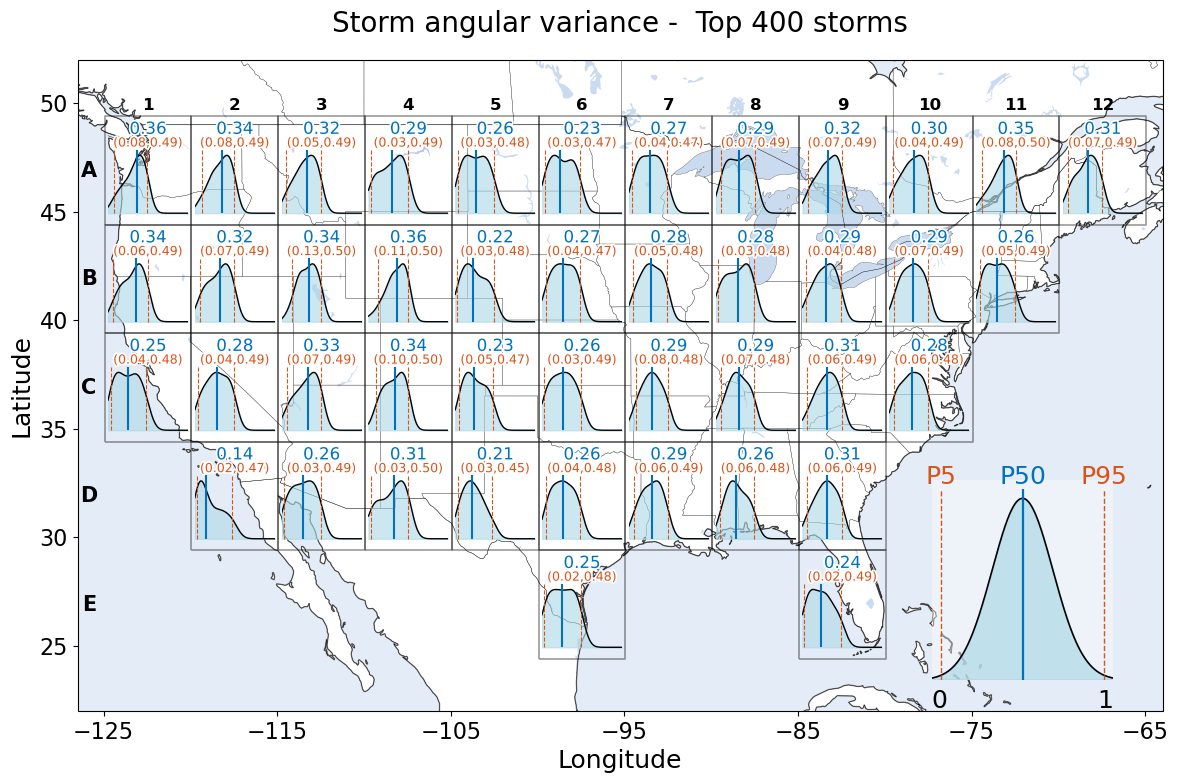

In [15]:
def kde_conus_plot(ax, storm_stats, domain_stats_all, var_name, x_max,f, domains, grid=None,
                   extent=(-126.5, -64, 22, 52),
                   data_crs=ccrs.PlateCarree(),
                   inset_frac=0.15,
                   top_storms=None,
                   percentiles="5-95"
                   ,percentile_labels=True,
                   linear_trajectory_threshold=0.51):
    
    var_df = {'speed':'storm_velocity', 'intensity':'mean_intensity', 'angular_var':'angular_variance_weighted'}

    # 1) Map extent in lon/lat -> use PlateCarree!
    ax.set_extent(extent, crs=data_crs)

    # 2) Base map (filled layers first, lines on top)
    ax.add_feature(cfeature.OCEAN, zorder=0, alpha=0.25)
    ax.add_feature(cfeature.LAND, zorder=1, facecolor = 'white', edgecolor="0.5", alpha=0.9)
    ax.add_feature(cfeature.LAKES, zorder=2, alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, zorder=3, linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, zorder=3, linewidth=0.3)
    ax.add_feature(cfeature.STATES, zorder=3, linewidth=0.2, edgecolor="0.2")

    if grid is not None:
        grid.boundary.plot(ax=ax, transform=data_crs, linewidth=1.2, alpha=0.4, color='black', zorder=4)

    # 3) Global x-limits for inset plots
    xmin_data = 0
    xmax_data = x_max
    #xmax_data = 10
    # keep the top storms only in storm stats
    
    # 4) One inset per cell
    for cat in grid['D_name']:
        # parse id & read
        cat_file = f'storm_properties_{cat}.csv'
        df = pd.read_csv(os.path.join(f, cat_file))
        df['id'] = df['storm_event'].str.split('_').str[3].astype(int)
        if top_storms is not None:
            df = df[df['id'] > 400 - top_storms]
        # filter by linear trajectory threshold
        if linear_trajectory_threshold is not None:
            df = df[df['angular_variance_weighted'] < linear_trajectory_threshold]
        lon = float(domains.loc[cat, 'x'])
        lat = float(domains.loc[cat, 'y'])


        # anchor point in parent axes data coords
        x, y = ax.projection.transform_point(lon, lat, src_crs=data_crs)
        inset_frac=0.7
        axins = inset_axes(
            ax,
            width=0.8,            # fraction of parent axes width
            height=0.7,           # fraction of parent axes height
            loc="center",
            bbox_to_anchor=(x, y-0.5), 
            bbox_transform=ax.transData, # <-- correct transform
            borderpad=0,
        
        )

        # x-range (same across all KDEs)
        axins.set_xlim(xmin_data, xmax_data)

        # your KDE/density function
        plot_density_on_ax(axins, df[var_df[var_name]].to_numpy(), percentiles = percentiles, percentile_labels=percentile_labels)

        # sparkline look
        axins.set_xticks([])
        axins.set_yticks([])
        for sp in axins.spines.values():
            sp.set_visible(False)
    #put  labels on top of the grid from 1 to 12
    for i in range(1, 13):
        cell = grid[(grid['row_index']==2.0) & (grid['col_index']==float(i-1))]
        x = (cell.right.values[0] + cell.left.values[0]) / 2  
        y = cell.top.values[0] + 0.5
        ax.text(x, y, str(i), fontsize=12, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())

    # put labels on left side from the grid from A to E
    for i, letter in enumerate(['A', 'B', 'C', 'D', 'E']):

        if i < 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==0.0)]
        elif i == 3:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==1.0)]
        else:
            cell = grid[(grid['row_index']==float(i+2)) & (grid['col_index']==5.0)]
        x = grid.loc[26].left - 0.9
        y = (cell.top.values[0] + cell.bottom.values[0]) / 2
        ax.text(x, y, letter, fontsize=15, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())
     # 5) Ticks/labels in lon/lat
    ax.set_xticks(np.arange(-125, -64 + 1, 10), crs=data_crs)
    ax.set_yticks(np.arange(25, 55, 5), crs=data_crs)
    ax.tick_params(axis='both', which='major', labelsize=16)
    title_var = {'speed':'speed', 'intensity':'rainfall intensity', 'angular_var':'angular variance'}
    ax.set_xlabel('Longitude', fontsize=18)
    ax.set_ylabel('Latitude', fontsize=18)
    title_tail = f" -  Top {top_storms} storms" if top_storms is not None else ""
    ax.set_title(f"Storm {title_var[var_name]}{title_tail}", fontsize=20, pad=20)



# Example usage
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
storm_stats = [file for file in os.listdir(f) if file.endswith('.csv')]
kde_conus_plot(ax, storm_stats, domain_stats_all, 'angular_var', 1, f, domains, grid=grid, top_storms=top_storms, linear_trajectory_threshold=0.51)

# Add a legend for the KDE inset plots
inset_ax = plt.axes([0.65, 0.2, 0.3, 0.2], projection=ccrs.PlateCarree())


plot_kde_legend(
    inset_ax,
    xlim=(0, 1),
    percentiles=(5, 50,  95),
    v_max=1,
    show_formula=False,
    fill_color="lightblue",
    line_color="black",
    p_median_color="#0072BD",
    p_other_color="#D95319",
    fontsize=18
)


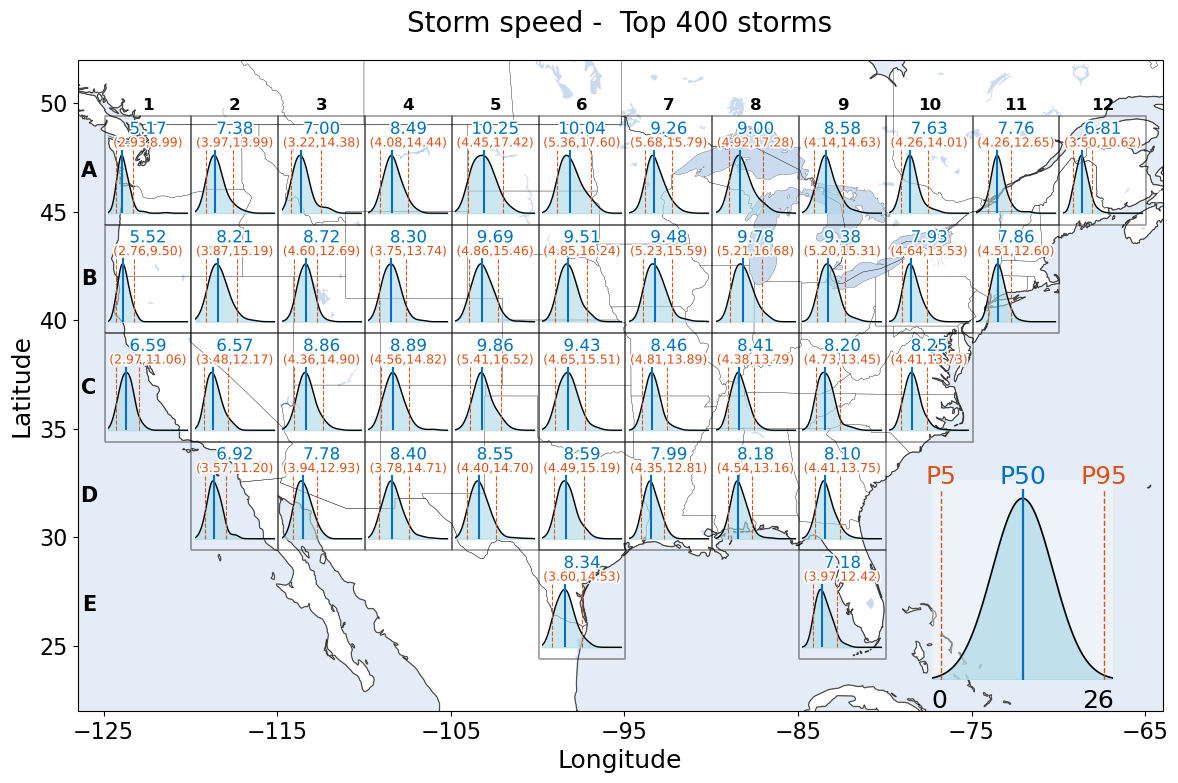

In [19]:
# Example usage
fig = plt.figure(figsize=(14, 10))
parent_projection = ccrs.PlateCarree()
ax = plt.axes(projection=parent_projection)
top_storms = 400
domain_stats_all = domain_stats_func(top_storms, filter_events=True, linear_trajectory_threshold=0.51)
storm_stats = [file for file in os.listdir(f) if file.endswith('.csv')]
kde_conus_plot(ax, storm_stats, domain_stats_all, 'speed', 29, f, domains, grid=grid, top_storms=top_storms, linear_trajectory_threshold=0.51)

# Add a legend for the KDE inset plots
inset_ax = plt.axes([0.65, 0.2, 0.3, 0.2], projection=ccrs.PlateCarree())

vmax = domain_stats_all['speed']['ALL']['max'].max()
plot_kde_legend(
    inset_ax,
    xlim=(0, 1),
    percentiles=(5, 50,  95),
    v_max=vmax,
    show_formula=False,
    fill_color="lightblue",
    line_color="black",
    p_median_color="#0072BD",
    p_other_color="#D95319",
    fontsize=18
)

In [12]:
domain_stats_all.keys()

dict_keys(['dir', 'speed', 'intensity', 'area', 'angular_var'])

In [ ]:
storm_stats